# PRISM OOD Analysis - Standalone
## Cross-Dataset Transfer: PCam↔MHIST | CRC↔BRACS
### Run independently - no dependency on main analysis notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive
drive.mount('/content/drive')

RESULTS_DIR = '/content/drive/MyDrive/PRISM/results'
FIGURES_DIR = '/content/drive/MyDrive/PRISM/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 150,
})

MODELS     = ['CLIP', 'PLIP', 'CONCH', 'VIRCHOW2', 'UNI', 'GigaPath', 'H-Optimus-0', 'MIDNIGHT']
MODEL_KEYS = ['clip', 'plip', 'conch', 'virchow2', 'uni', 'gigapath', 'h_optimus_0', 'midnight']

MODEL_COLORS = {
    'CLIP':        '#e41a1c',
    'PLIP':        '#ff7f00',
    'CONCH':       '#4daf4a',
    'VIRCHOW2':    '#984ea3',
    'UNI':         '#377eb8',
    'GigaPath':    '#a65628',
    'H-Optimus-0': '#f781bf',
    'MIDNIGHT':    '#999999',
}

OOD_PAIRS = [
    ('PCam',  'MHIST', 'pcam',  'mhist'),
    ('MHIST', 'PCam',  'mhist', 'pcam'),
    ('CRC',   'BRACS', 'crc',   'bracs'),
    ('BRACS', 'CRC',   'bracs', 'crc'),
]

print("Setup OK!")

Mounted at /content/drive
Setup OK!


In [2]:
# Load in-domain results (for AUROC drop comparison)
DS_KEYS = ['pcam', 'bracs', 'crc', 'mhist', 'lunghist700', 'spider_breast']
DATASETS = ['PCam', 'BRACS', 'CRC', 'MHIST', 'LungHist700', 'SPIDER-Breast']

# Naming exception for H-Optimus-0 PCam
NAMING_EXCEPTIONS = {('h_optimus_0', 'pcam'): 'hoptimus'}

id_results = []
for model, mkey in zip(MODELS, MODEL_KEYS):
    for ds, dkey in zip(DATASETS, DS_KEYS):
        actual_key = NAMING_EXCEPTIONS.get((mkey, dkey), mkey)
        res_path = f'{RESULTS_DIR}/{actual_key}_{dkey}_results.csv'
        if os.path.exists(res_path):
            df = pd.read_csv(res_path)
            df['model']   = model
            df['dataset'] = ds
            id_results.append(df)

df_id = pd.concat(id_results, ignore_index=True)
id_summary = df_id.groupby(['model','dataset','fraction'])['auroc'].mean().reset_index()

# Build lookup: (model, dataset) -> AUROC at 100%
id_auroc = {}
for model in MODELS:
    for ds in DATASETS:
        row = id_summary[(id_summary['model']==model) &
                         (id_summary['dataset']==ds) &
                         (id_summary['fraction']==1.0)]
        if len(row):
            id_auroc[(model, ds)] = row['auroc'].values[0]

print(f"In-domain results loaded: {len(df_id)} rows")
print("Sample AUROC@100%:")
for (m, ds), v in list(id_auroc.items())[:6]:
    print(f"  {m:15s} {ds:10s}: {v:.4f}")

In-domain results loaded: 864 rows
Sample AUROC@100%:
  CLIP            PCam      : 0.9166
  CLIP            BRACS     : 0.8138
  CLIP            CRC       : 0.9976
  CLIP            MHIST     : 0.8535
  CLIP            LungHist700: 0.8354
  CLIP            SPIDER-Breast: 0.9640


In [3]:
# Load all OOD results
ood_results = []
ood_ts_results = []
ood_missing = []

for model, mkey in zip(MODELS, MODEL_KEYS):
    for src_name, tgt_name, src_key, tgt_key in OOD_PAIRS:
        tag = f"{mkey}_ood_{src_key}_to_{tgt_key}"
        res_path = f"{RESULTS_DIR}/{tag}_results.csv"
        ts_path  = f"{RESULTS_DIR}/{tag}_temperature_scaling.csv"
        if os.path.exists(res_path) and os.path.exists(ts_path):
            df_r = pd.read_csv(res_path)
            df_t = pd.read_csv(ts_path)
            for df in [df_r, df_t]:
                df['model'] = model
                df['src']   = src_name
                df['tgt']   = tgt_name
                df['pair']  = f"{src_name}\u2192{tgt_name}"
            ood_results.append(df_r)
            ood_ts_results.append(df_t)
        else:
            ood_missing.append(f"{model} {src_name}>{tgt_name}")

df_ood    = pd.concat(ood_results,    ignore_index=True)
df_ood_ts = pd.concat(ood_ts_results, ignore_index=True)

# Mean over 3 seeds
ood_summary    = df_ood.groupby(['model','pair','fraction'])[['auroc','ece','f1','brier']].mean().reset_index()
ood_ts_summary = df_ood_ts.groupby(['model','pair','fraction'])[['temperature','ece_raw','ece_scaled','ece_improvement']].mean().reset_index()

print(f"OOD rows: {len(df_ood)}")
print(f"Missing: {ood_missing if ood_missing else 'None'}")
print(f"Pairs: {sorted(df_ood['pair'].unique())}")

OOD rows: 576
Missing: None
Pairs: ['BRACS→CRC', 'CRC→BRACS', 'MHIST→PCam', 'PCam→MHIST']


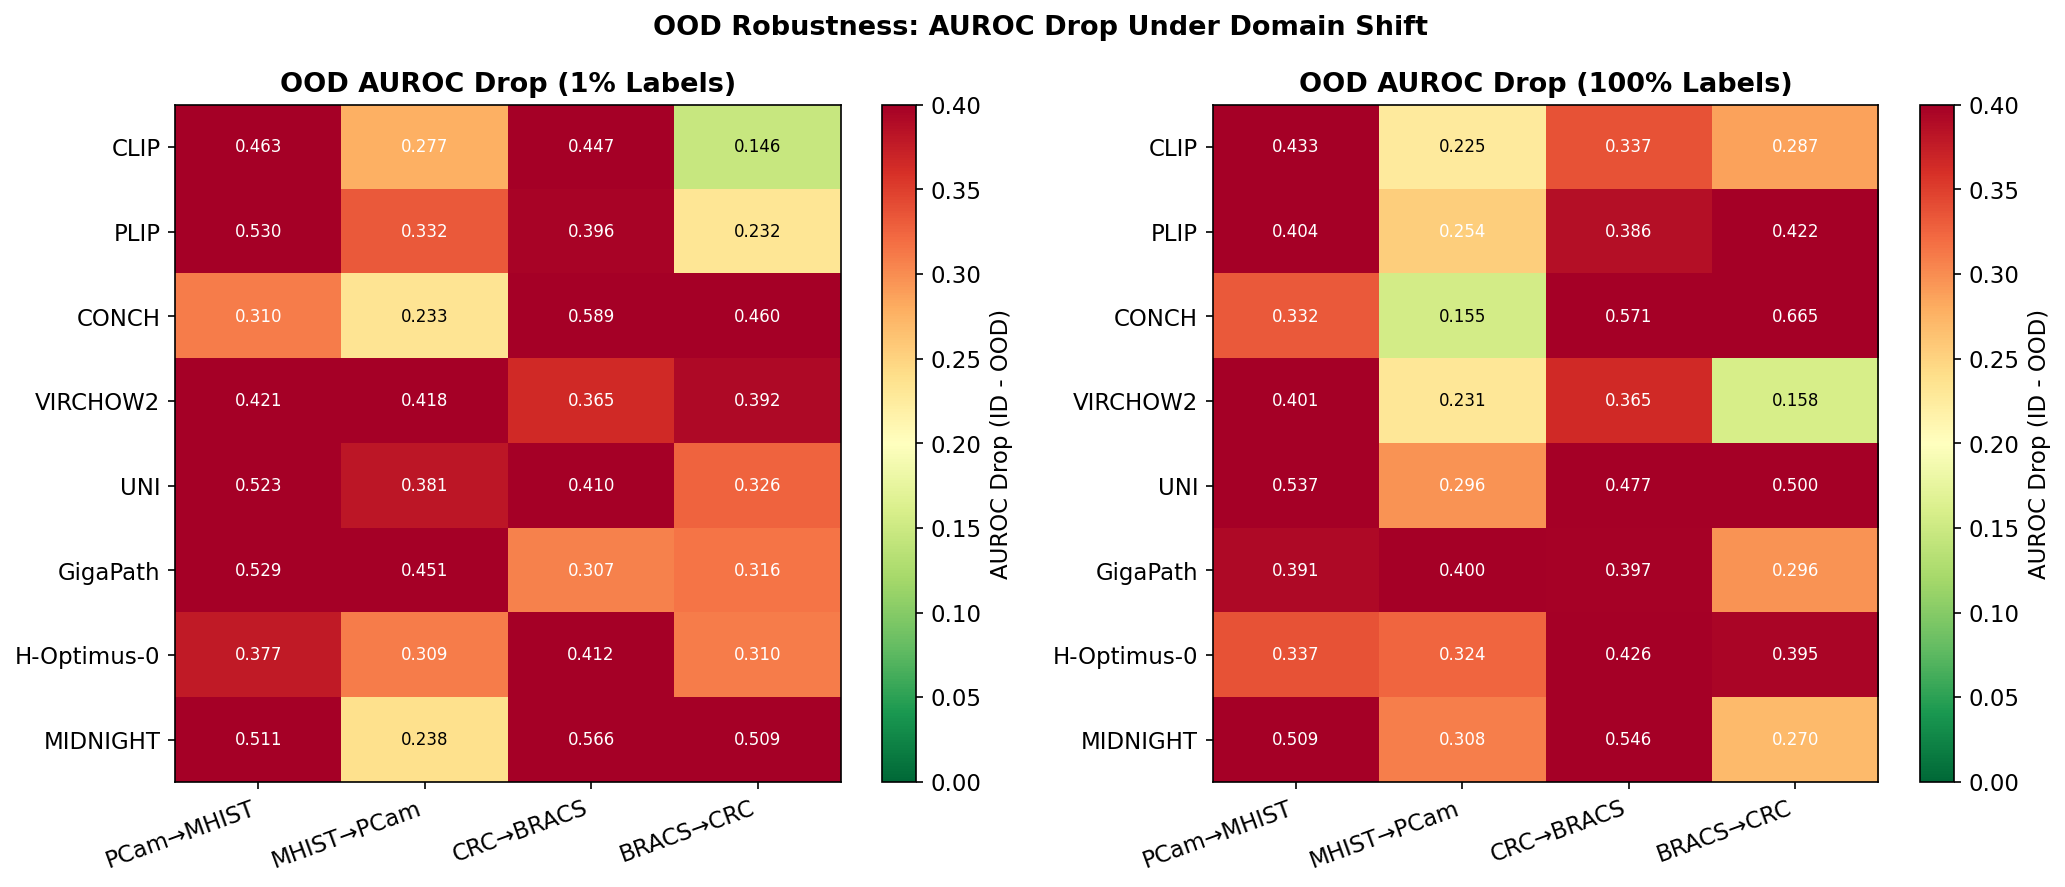

Saved: ood_auroc_drop.pdf/png


In [4]:
# Figure 8a: OOD AUROC Drop Heatmap
pair_labels = ['PCam→MHIST', 'MHIST→PCam', 'CRC→BRACS', 'BRACS→CRC']
src_labels  = ['PCam', 'MHIST', 'CRC', 'BRACS']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (frac, frac_label) in enumerate([(0.01, '1% Labels'), (1.00, '100% Labels')]):
    ax = axes[ax_idx]
    drop_mat = np.zeros((len(MODELS), 4))

    for i, model in enumerate(MODELS):
        for j, (pair, src) in enumerate(zip(pair_labels, src_labels)):
            ood_row = ood_summary[(ood_summary['model']==model) &
                                  (ood_summary['pair']==pair) &
                                  (ood_summary['fraction']==frac)]
            if len(ood_row):
                ood_auroc = ood_row['auroc'].values[0]
                id_auc    = id_auroc.get((model, src), np.nan)
                drop_mat[i,j] = id_auc - ood_auroc

    im = ax.imshow(drop_mat, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.4)
    ax.set_xticks(range(4)); ax.set_xticklabels(pair_labels, rotation=20, ha='right')
    ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(MODELS)
    ax.set_title(f'OOD AUROC Drop ({frac_label})', fontweight='bold')

    for i in range(len(MODELS)):
        for j in range(4):
            val = drop_mat[i,j]
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                   fontsize=8, color='white' if val > 0.25 else 'black')
    plt.colorbar(im, ax=ax, label='AUROC Drop (ID - OOD)')

plt.suptitle('OOD Robustness: AUROC Drop Under Domain Shift', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ood_auroc_drop.pdf', bbox_inches='tight', dpi=150)
plt.savefig(f'{FIGURES_DIR}/ood_auroc_drop.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: ood_auroc_drop.pdf/png")

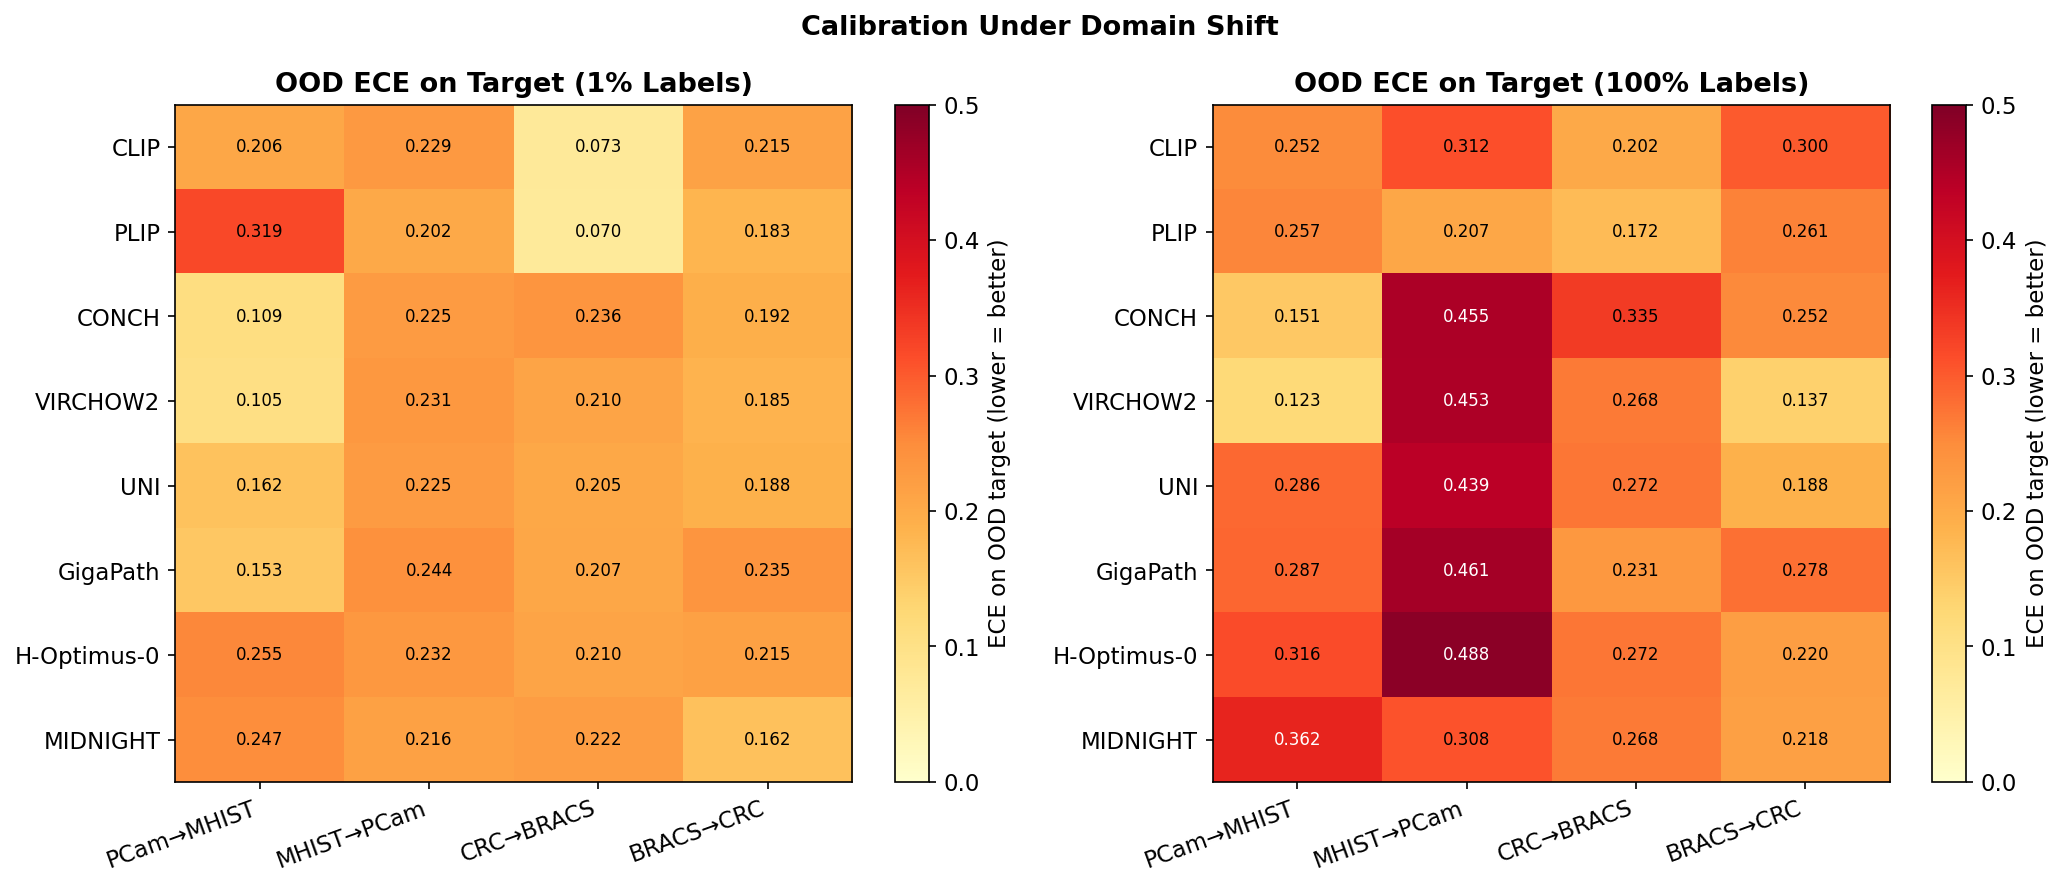

Saved: ood_ece_heatmap.pdf/png


In [5]:
# Figure 8b: OOD ECE Heatmap (calibration under shift)
pair_labels = ['PCam→MHIST', 'MHIST→PCam', 'CRC→BRACS', 'BRACS→CRC']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (frac, frac_label) in enumerate([(0.01, '1% Labels'), (1.00, '100% Labels')]):
    ax = axes[ax_idx]
    ece_mat = np.zeros((len(MODELS), 4))

    for i, model in enumerate(MODELS):
        for j, pair in enumerate(pair_labels):
            row = ood_ts_summary[(ood_ts_summary['model']==model) &
                                 (ood_ts_summary['pair']==pair) &
                                 (ood_ts_summary['fraction']==frac)]
            if len(row):
                ece_mat[i,j] = row['ece_raw'].values[0]

    im = ax.imshow(ece_mat, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.5)
    ax.set_xticks(range(4)); ax.set_xticklabels(pair_labels, rotation=20, ha='right')
    ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(MODELS)
    ax.set_title(f'OOD ECE on Target ({frac_label})', fontweight='bold')

    for i in range(len(MODELS)):
        for j in range(4):
            val = ece_mat[i,j]
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                   fontsize=8, color='white' if val > 0.35 else 'black')
    plt.colorbar(im, ax=ax, label='ECE on OOD target (lower = better)')

plt.suptitle('Calibration Under Domain Shift', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ood_ece_heatmap.pdf', bbox_inches='tight', dpi=150)
plt.savefig(f'{FIGURES_DIR}/ood_ece_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: ood_ece_heatmap.pdf/png")

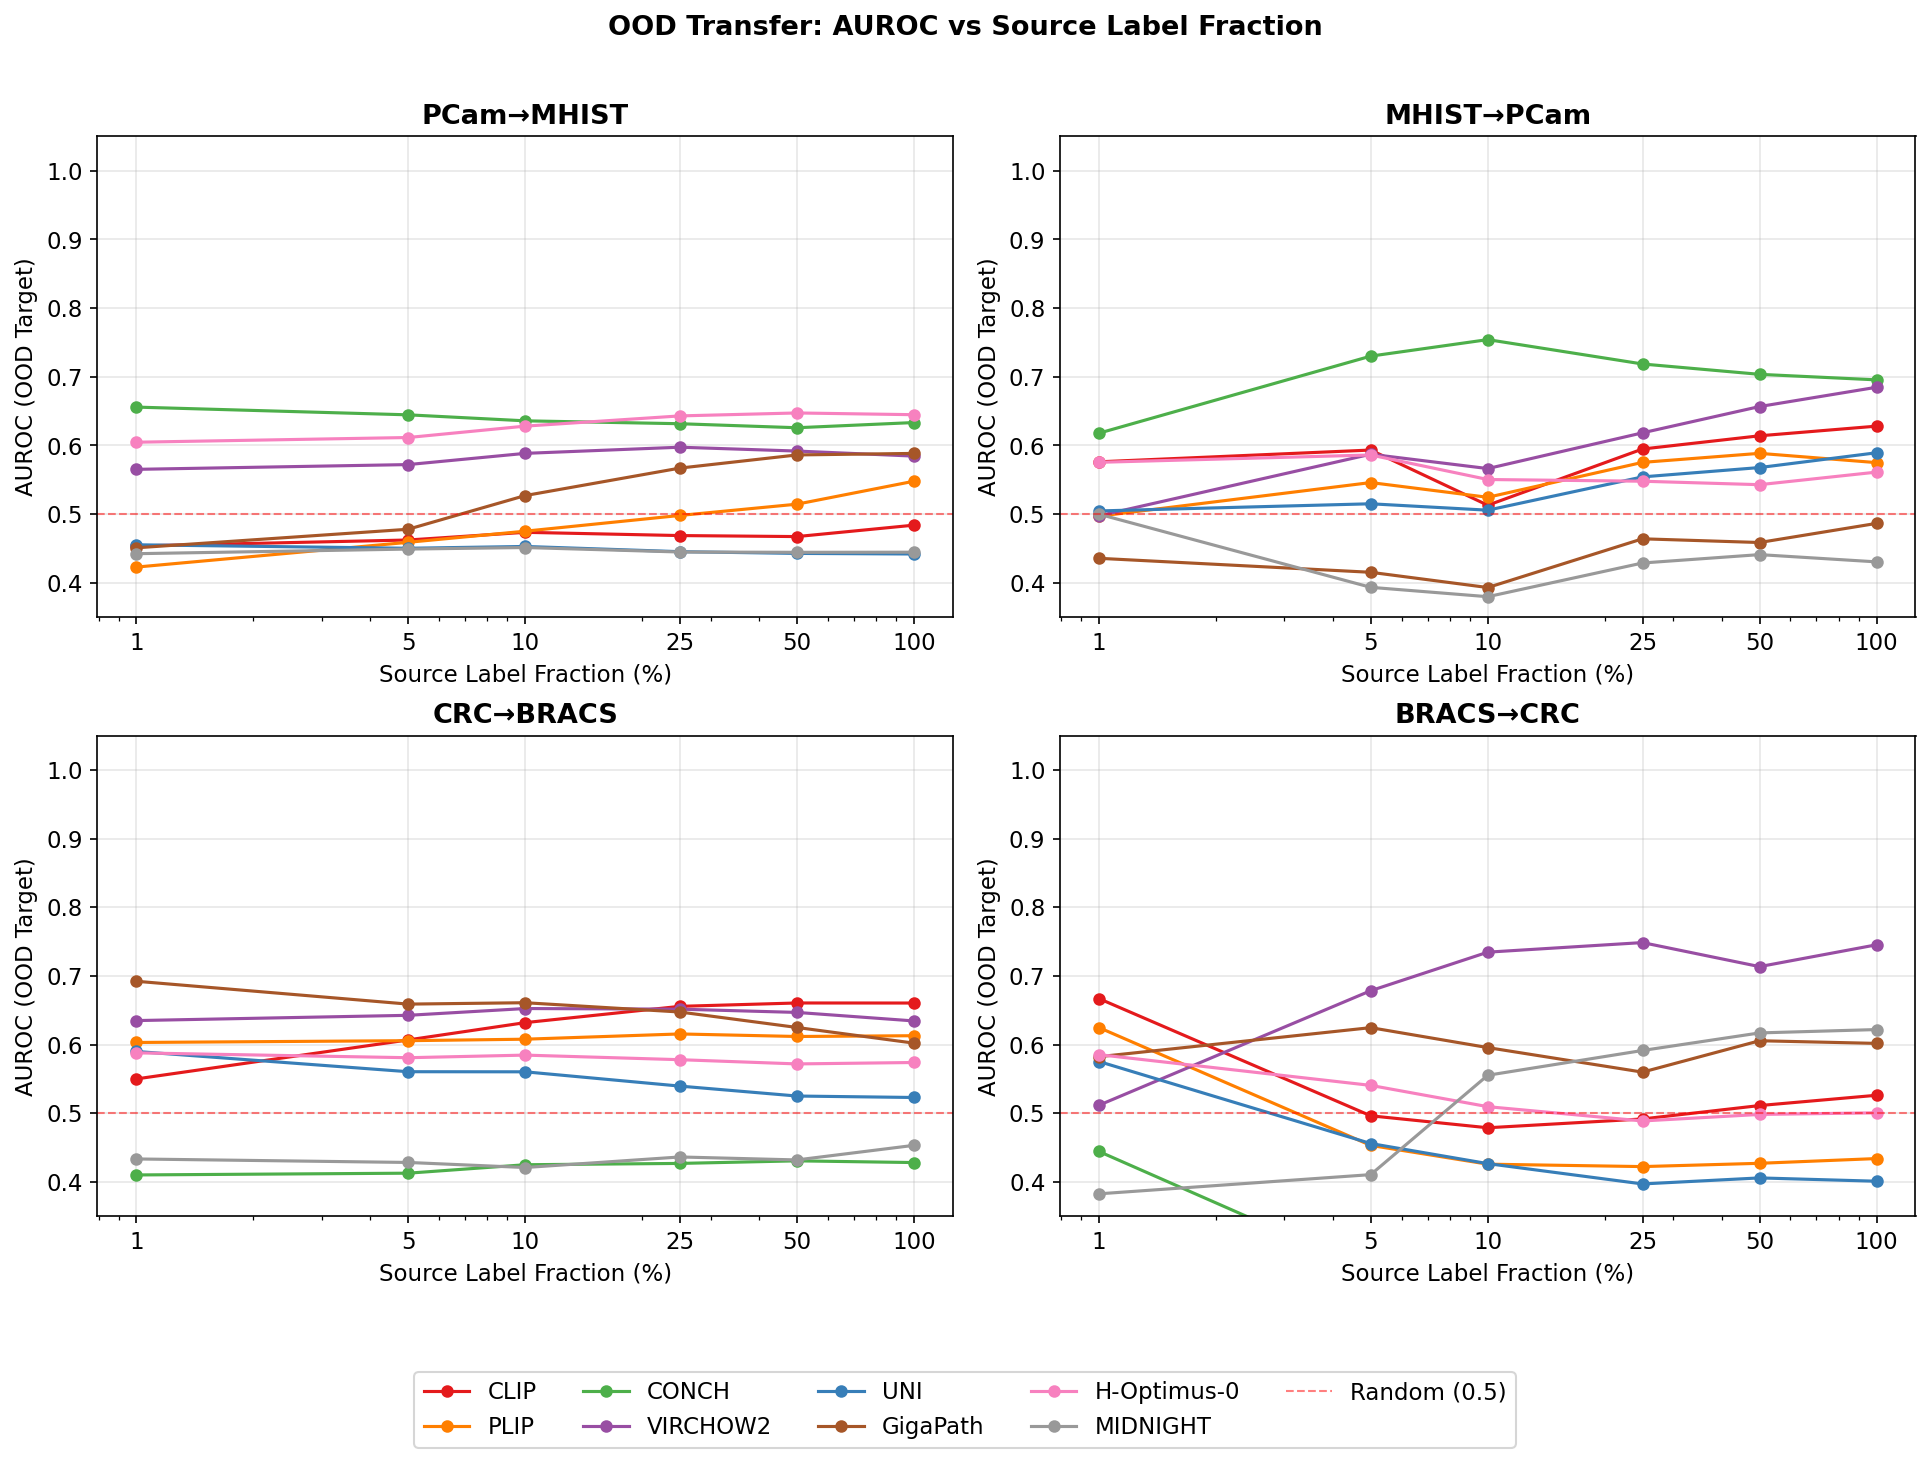

Saved: ood_auroc_curves.pdf/png


In [6]:
# Figure 8c: OOD Transfer Curves - AUROC vs Label Fraction
pair_labels = ['PCam→MHIST', 'MHIST→PCam', 'CRC→BRACS', 'BRACS→CRC']
fractions   = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax_idx, pair in enumerate(pair_labels):
    ax = axes[ax_idx]
    for model in MODELS:
        vals = []
        for frac in fractions:
            row = ood_summary[(ood_summary['model']==model) &
                              (ood_summary['pair']==pair) &
                              (ood_summary['fraction']==frac)]
            vals.append(row['auroc'].values[0] if len(row) else np.nan)
        ax.plot([f*100 for f in fractions], vals,
                marker='o', markersize=5,
                color=MODEL_COLORS[model], label=model, linewidth=1.5)

    ax.set_title(pair, fontweight='bold')
    ax.set_xlabel('Source Label Fraction (%)')
    ax.set_ylabel('AUROC (OOD Target)')
    ax.set_xscale('log')
    ax.set_xticks([1, 5, 10, 25, 50, 100])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_ylim(0.35, 1.05)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Random (0.5)')
    ax.grid(True, alpha=0.3)

handles, labels_list = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_list, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.06))
plt.suptitle('OOD Transfer: AUROC vs Source Label Fraction', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig(f'{FIGURES_DIR}/ood_auroc_curves.pdf', bbox_inches='tight', dpi=150)
plt.savefig(f'{FIGURES_DIR}/ood_auroc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: ood_auroc_curves.pdf/png")

In [7]:
# OOD Summary Table - paper-ready
pair_labels = ['PCam→MHIST', 'MHIST→PCam', 'CRC→BRACS', 'BRACS→CRC']
src_map     = dict(zip(pair_labels, ['PCam', 'MHIST', 'CRC', 'BRACS']))

print("=== OOD AUROC Drop (ID@100% minus OOD@100%) ===\n")
rows = []
for model in MODELS:
    row = {'Model': model}
    drops = []
    for pair in pair_labels:
        ood_row = ood_summary[(ood_summary['model']==model) &
                              (ood_summary['pair']==pair) &
                              (ood_summary['fraction']==1.0)]
        if len(ood_row):
            ood_auc = ood_row['auroc'].values[0]
            id_auc  = id_auroc.get((model, src_map[pair]), np.nan)
            drop    = id_auc - ood_auc
            row[pair] = round(drop, 3)
            drops.append(drop)
    row['Mean Drop'] = round(np.mean(drops), 3)
    rows.append(row)

tbl = pd.DataFrame(rows).set_index('Model')
print(tbl.to_string())
tbl.to_csv(f'{RESULTS_DIR}/ood_drop_summary.csv')

print("\n=== Ranking by OOD Robustness (lowest drop = most robust) ===")
for m, d in sorted([(r['Model'], r['Mean Drop']) for r in rows], key=lambda x: x[1]):
    bar = '█' * int(d * 50)
    print(f"  {m:15s}: {d:.3f} {bar}")

=== OOD AUROC Drop (ID@100% minus OOD@100%) ===

             PCam→MHIST  MHIST→PCam  CRC→BRACS  BRACS→CRC  Mean Drop
Model                                                               
CLIP              0.433       0.225      0.337      0.287      0.321
PLIP              0.404       0.254      0.386      0.422      0.367
CONCH             0.332       0.155      0.571      0.665      0.431
VIRCHOW2          0.401       0.231      0.365      0.158      0.289
UNI               0.537       0.296      0.477      0.500      0.452
GigaPath          0.391       0.400      0.397      0.296      0.371
H-Optimus-0       0.337       0.324      0.426      0.395      0.370
MIDNIGHT          0.509       0.308      0.546      0.270      0.408

=== Ranking by OOD Robustness (lowest drop = most robust) ===
  VIRCHOW2       : 0.289 ██████████████
  CLIP           : 0.321 ████████████████
  PLIP           : 0.367 ██████████████████
  H-Optimus-0    : 0.370 ██████████████████
  GigaPath       : 0.371 ███